In this script, we will:

* calculate the Top of the Atmosphere (TOA) Radiative Imbalance in the x4CO2 forcing scenario,

* calculate the Atmosphere and Ocean heat transports and their change during time and

* explore an alternative way of assesing Bjerknes Compensation.

***This script uses data specifically from the CESM2 model.**

### **0.1. Importing packages and functions**

In [1]:
# For skiping running a certain cell
from IPython.core.magic import register_cell_magic
@register_cell_magic
def comment(line, cell):
    return
    
# The functions we made in separate modules (including some more packages as well)
import sys
sys.path.append('/home/chrikap/Desktop/atmospheric heat transport/heat transport datasets/Annual_Variations/CMIP6/Paper_Scripts')

#from AHT_functions import *
from BJC_functions import *
#from OHT_functions import *
from Long_CMIP6_functions import *

# Reloading the module automatically, even though we might have changed it
%reload_ext autoreload
%autoreload 2

### **0.2. Importing the heat flux data from pangeo**

In [2]:
#%%comment
cat_url = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
col = intake.open_esm_datastore(cat_url)
col

,unique
activity_id,18
institution_id,36
source_id,88
experiment_id,170
member_id,657
table_id,37
variable_id,700
grid_label,10
zstore,514818
dcpp_init_year,60


In [3]:
experiment_id = ['piControl', 'abrupt-4xCO2']

variable_id = ['rlut', 'rsdt', 'rsut', 'hfls', 'hfss', 'rlds', 'rlus', 'rsds', 'rsus'] 

In [4]:
#%%comment

# Sorting the data alphabetically, making sure we've got what we need

cat1 = col.search(experiment_id = experiment_id, table_id = 'Amon', variable_id = variable_id, activity_id = 'CMIP', member_id = 'r1i1p1f1', source_id = 'CESM2') 

data = cat1.df

df_sorted = data.sort_values(by=[data.columns[2], data.columns[3]], ascending=True)

# Reset index
df_sorted.reset_index(drop=True, inplace=True)

HTML(df_sorted.to_html())

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,CMIP,NCAR,CESM2,abrupt-4xCO2,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/abrupt-4xCO2/r1i1p1f1/Amon/rsds/gn/v20190927/,NaN,20190927
1,CMIP,NCAR,CESM2,abrupt-4xCO2,r1i1p1f1,Amon,rlut,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/abrupt-4xCO2/r1i1p1f1/Amon/rlut/gn/v20190927/,NaN,20190927
2,CMIP,NCAR,CESM2,abrupt-4xCO2,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/abrupt-4xCO2/r1i1p1f1/Amon/rlus/gn/v20190927/,NaN,20190927
3,CMIP,NCAR,CESM2,abrupt-4xCO2,r1i1p1f1,Amon,hfls,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/abrupt-4xCO2/r1i1p1f1/Amon/hfls/gn/v20190927/,NaN,20190927
4,CMIP,NCAR,CESM2,abrupt-4xCO2,r1i1p1f1,Amon,hfss,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/abrupt-4xCO2/r1i1p1f1/Amon/hfss/gn/v20190927/,NaN,20190927
5,CMIP,NCAR,CESM2,abrupt-4xCO2,r1i1p1f1,Amon,rsdt,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/abrupt-4xCO2/r1i1p1f1/Amon/rsdt/gn/v20190927/,NaN,20190927
6,CMIP,NCAR,CESM2,abrupt-4xCO2,r1i1p1f1,Amon,rsus,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/abrupt-4xCO2/r1i1p1f1/Amon/rsus/gn/v20190927/,NaN,20190927
7,CMIP,NCAR,CESM2,abrupt-4xCO2,r1i1p1f1,Amon,rsut,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/abrupt-4xCO2/r1i1p1f1/Amon/rsut/gn/v20190927/,NaN,20190927
8,CMIP,NCAR,CESM2,abrupt-4xCO2,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/abrupt-4xCO2/r1i1p1f1/Amon/rlds/gn/v20190927/,NaN,20190927
9,CMIP,NCAR,CESM2,piControl,r1i1p1f1,Amon,rsut,gn,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/piControl/r1i1p1f1/Amon/rsut/gn/v20190320/,NaN,20190320


In [5]:
#%%comment

# Loading the data, putting everything into a list

dset_dict = cat1.to_dataset_dict(zarr_kwargs={'consolidated': True})
models_experiments_list = list(dset_dict.keys())


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


In [6]:
#%%comment
# Model names

# Function to extract model name
def extract_model_name(string_name):
    return string_name.split('.')[2]
    
models_experiments = []

for dataset in models_experiments_list:
    names = dataset.split('.')    
    dataset_name = names[2] + '.' + names[3]        
    models_experiments.append(dataset_name)

### **0.3. Organising the data**

In [7]:
#%%comment

# Separating the datasets in piControl, x4CO2 lists and sorting them in alphabetical order.

ds_piControl = []
ds_x4CO2 = []

# Extracting the names of models from the dataset names

piControl_names = [name for name in models_experiments_list if 'piControl' in name]
abrupt4xCO2_names = [name for name in models_experiments_list if 'abrupt-4xCO2' in name]

# Now, we can sort the lists alphabetically by the MODEL name and not just the dataframe name

piControl_names.sort(key=extract_model_name)
abrupt4xCO2_names.sort(key=extract_model_name)

# Dropping everything in the correct list

for i, j in zip(piControl_names, abrupt4xCO2_names):
    
    ds_piControl.append(dset_dict[i])
    ds_x4CO2.append(dset_dict[j])

## **Part 1: The TOA Radiative Imbalance**

### **1.1. Calculating the ATM heat fluxes, using the pangeo database**

In [8]:
#%%comment

experiments = [ds_piControl, ds_x4CO2]

# The different heat fluxes needed:
components = variable_id

# Choosing the time period

start_y = 0
end_y = 999*12

# Grabbing lon, lat first:
lon = experiments[0][0]['lon'].values
lat = experiments[0][0]['lat'].values

In [9]:
#%%comment

atm_fluxes_exp = []

for experiment in experiments:
        
    # Select 50-year slice for performance
    ds = experiment[0].isel(time=slice(start_y, end_y))
    ds = ds.chunk({
        "time": 120,      
        "lat": 100,    
        "lon": 100,
    })
                 
    atm_fluxes = []
        
    for component in components:

        ds_yearly = yearly_avg(ds[component][0, 0, :, :, :])
        atm_fluxes.append(ds_yearly) 

    atm_fluxes_exp.append(atm_fluxes)

In [10]:
lat_cesm2 = ds_yearly['lat']

In [11]:
#%%comment
# Calculating the heat fluxes lat, lon - dependent
for i, name in enumerate(variable_id):
    globals()[f"{name}_piControl"] = atm_fluxes_exp[0][i]
    globals()[f"{name}_x4CO2"] = atm_fluxes_exp[1][i]

In [12]:
# Calculating the zonal average of each heat flux
for i, name in enumerate(variable_id):

    globals()[f"{name}_zon_piControl"] = np.mean(atm_fluxes_exp[0][i], axis = -1)
    globals()[f"{name}_zon_x4CO2"] = np.mean(atm_fluxes_exp[1][i], axis = -1)

### **1.2. Calculating the TOA radiative Imbalance**

We calculate this as the global mean of the TOA radiative forces (rsdt-rsut-rlut)

In [26]:
os.chdir('/home/chrikap/Desktop/atmospheric heat transport/heat transport datasets/Annual_Variations/CMIP6/Paper_Scripts/long_scale_cesm2')

#rsdt_x4CO2.to_netcdf("rsdt.nc")
#rlut_x4CO2.to_netcdf("rlut.nc")
#rsut_x4CO2.to_netcdf("rsut.nc")

In [27]:
os.chdir('/home/chrikap/Desktop/atmospheric heat transport/heat transport datasets/Annual_Variations/CMIP6/Paper_Scripts/long_scale_cesm2')

rsdt_x4CO2 = xr.open_dataarray("rsdt.nc", chunks="auto")
rlut_x4CO2 = xr.open_dataarray("rlut.nc", chunks="auto")
rsut_x4CO2 = xr.open_dataarray("rsut.nc", chunks="auto")

In [30]:
toa_rad = rsdt_x4CO2-rlut_x4CO2-rsut_x4CO2

sh = toa_rad.sel(lat=slice(None,0)) 
nh = toa_rad.sel(lat=slice(0,None))

In [31]:
sh_imb = areaavg(sh.to_dataset(name = "restom"), "restom")#.compute()
nh_imb = areaavg(nh.to_dataset(name = "restom"), "restom")#.compute()
glb_imb = areaavg(toa_rad.to_dataset(name = "restom"), "restom")#.compute()

In [47]:
sh_imb = sh_imb.values
nh_imb = nh_imb.values
glb_imb = glb_imb.values

np.save('sh_imb', sh_imb)
np.save('nh_imb', nh_imb)
np.save('glb_imb', glb_imb)

In [48]:
# Applying an 11-y rolling mean to the timeseries to get rid of less-than-decadal variability

roll_glb_imb_cesm2 = rolling_average_ts(glb_imb, 11)
roll_nh_imb_cesm2 = rolling_average_ts(nh_imb, 11)
roll_sh_imb_cesm2 = rolling_average_ts(sh_imb, 11)

In [ ]:
os.chdir('/home/chrikap/Desktop/atmospheric heat transport/heat transport datasets/Annual_Variations/CMIP6/Paper_Scripts/long_scale_cesm2')

np.save('roll_glb_imb_cesm2', roll_glb_imb_cesm2)
np.save('roll_nh_imb_cesm2', roll_nh_imb_cesm2)
np.save('roll_sh_imb_cesm2', roll_sh_imb_cesm2)

In [10]:
os.chdir('/home/chrikap/Desktop/atmospheric heat transport/heat transport datasets/Annual_Variations/CMIP6/Paper_Scripts/long_scale_cesm2')

roll_glb_imb_cesm2 = np.load('roll_glb_imb_cesm2.npy')
roll_nh_imb_cesm2 = np.load('roll_nh_imb_cesm2.npy')
roll_sh_imb_cesm2 = np.load('roll_sh_imb_cesm2.npy')

In [ ]:
### be vary careful of the rolling average here!!!

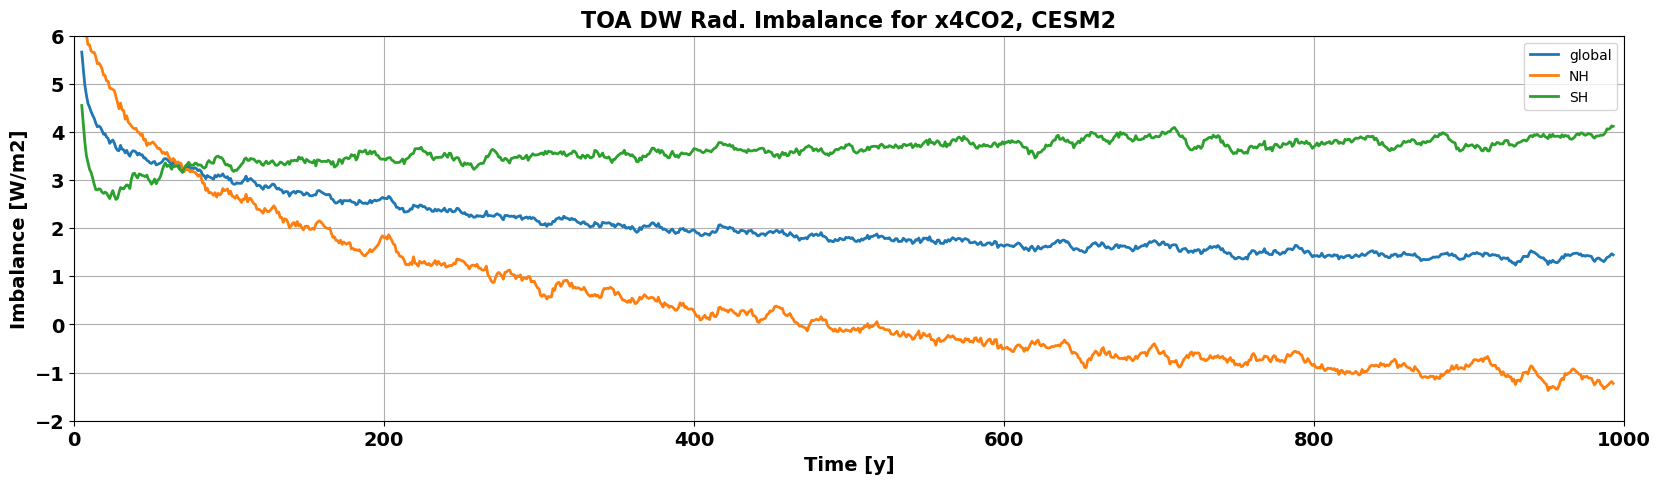

In [11]:
time = np.arange(5, 994)

plt.figure(figsize=(20, 5))

plt.plot(time, roll_glb_imb_cesm2, linewidth = 2, label='global')
plt.plot(time, roll_nh_imb_cesm2, linewidth = 2, label='NH')
plt.plot(time, roll_sh_imb_cesm2, linewidth = 2, label='SH')
plt.xlim(0, 1000)
plt.ylim(-2, 6)

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('Imbalance [W/m2]', fontsize=14, fontweight='bold')
plt.title('TOA DW Rad. Imbalance for x4CO2, CESM2', fontsize=16, fontweight='bold')

plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

plt.legend()
plt.grid()

### **Part 2: The Atmosphere Heat Transport**

### **2.1. Calculation in chuncks**
The calculation is heavy, so we need to work with few years at a time. I'm working with 100/200 year chunks here

In [32]:
toa_zonal_ave_piControl = rsdt_zon_piControl-rlut_zon_piControl-rsut_zon_piControl
atm_zonal_ave_piControl = toa_zonal_ave_piControl + hfls_zon_piControl + hfss_zon_piControl + rlus_zon_piControl+rsus_zon_piControl-\
                          (rlds_zon_piControl+ rsds_zon_piControl)

#toa_ht_piControl_i = heat_transport_vect('CESM2', toa_zonal_ave_piControl[0:500], lat)
#toa_ht_piControl_ii = heat_transport_vect('CESM2', toa_zonal_ave_piControl[500:], lat)

#atm_ht_piControl_i = heat_transport_vect('CESM2', atm_zonal_ave_piControl[0:100], lat)
#atm_ht_piControl_ii = heat_transport_vect('CESM2', atm_zonal_ave_piControl[100:200], lat)
#atm_ht_piControl_iii = heat_transport_vect('CESM2', atm_zonal_ave_piControl[200:300], lat)
#atm_ht_piControl_iv = heat_transport_vect('CESM2', atm_zonal_ave_piControl[300:400], lat)
#atm_ht_piControl_v = heat_transport_vect('CESM2', atm_zonal_ave_piControl[400:500], lat)
#atm_ht_piControl_vi = heat_transport_vect('CESM2', atm_zonal_ave_piControl[500:600], lat)
#atm_ht_piControl_vii = heat_transport_vect('CESM2', atm_zonal_ave_piControl[600:700], lat)
#atm_ht_piControl_viii = heat_transport_vect('CESM2', atm_zonal_ave_piControl[700:800], lat)
#atm_ht_piControl_ix = heat_transport_vect('CESM2', atm_zonal_ave_piControl[800:900], lat)
atm_ht_piControl_x = heat_transport_vect('CESM2', atm_zonal_ave_piControl[900:], lat)

In [33]:
os.chdir('/home/chrikap/Desktop/atmospheric heat transport/heat transport datasets/Annual_Variations/CMIP6/Paper_Scripts/long_scale_cesm2')
#np.save('toa_ht_piControl_i', toa_ht_piControl_i)
#np.save('toa_ht_piControl_ii', toa_ht_piControl_ii)
#np.save('atm_ht_piControl_i', atm_ht_piControl_i)
#np.save('atm_ht_piControl_ii', atm_ht_piControl_ii)
#np.save('atm_ht_piControl_iii', atm_ht_piControl_iii)
#np.save('atm_ht_piControl_iv', atm_ht_piControl_iv)
#np.save('atm_ht_piControl_v', atm_ht_piControl_v)
#np.save('atm_ht_piControl_vi', atm_ht_piControl_vi)
#np.save('atm_ht_piControl_vii', atm_ht_piControl_vii)
#np.save('atm_ht_piControl_vii', atm_ht_piControl_vii)
#np.save('atm_ht_piControl_viii', atm_ht_piControl_viii)
#np.save('atm_ht_piControl_ix', atm_ht_piControl_ix)
np.save('atm_ht_piControl_x', atm_ht_piControl_x)

In [35]:
toa_ht_piControl_i     = np.load('toa_ht_piControl_i.npy')
toa_ht_piControl_ii    = np.load('toa_ht_piControl_ii.npy')
atm_ht_piControl_i     = np.load('atm_ht_piControl_i.npy')
atm_ht_piControl_ii    = np.load('atm_ht_piControl_ii.npy')
atm_ht_piControl_iii   = np.load('atm_ht_piControl_iii.npy')
atm_ht_piControl_iv    = np.load('atm_ht_piControl_iv.npy')
atm_ht_piControl_v     = np.load('atm_ht_piControl_v.npy')
atm_ht_piControl_vi    = np.load('atm_ht_piControl_vi.npy')
atm_ht_piControl_vii   = np.load('atm_ht_piControl_vii.npy')
atm_ht_piControl_vii   = np.load('atm_ht_piControl_vii.npy')
atm_ht_piControl_viii  = np.load('atm_ht_piControl_viii.npy')
atm_ht_piControl_ix    = np.load('atm_ht_piControl_ix.npy')
atm_ht_piControl_x     = np.load('atm_ht_piControl_x.npy')

In [44]:
toa_ht_piControl = np.concatenate((toa_ht_piControl_i, toa_ht_piControl_ii), axis = 0)

atm_ht_piControl = np.concatenate((atm_ht_piControl_i, atm_ht_piControl_ii, atm_ht_piControl_iii, atm_ht_piControl_iv, atm_ht_piControl_v,
atm_ht_piControl_vi, atm_ht_piControl_vii, atm_ht_piControl_viii, atm_ht_piControl_ix, atm_ht_piControl_x), axis = 0)

In [19]:
toa_zonal_ave_x4CO2 = rsdt_zon_x4CO2-rlut_zon_x4CO2-rsut_zon_x4CO2
atm_zonal_ave_x4CO2 = toa_zonal_ave_x4CO2 + hfls_zon_x4CO2 + hfss_zon_x4CO2 + rlus_zon_x4CO2+rsus_zon_x4CO2-\
                          (rlds_zon_x4CO2+ rsds_zon_x4CO2)
#toa_ht_x4CO2_i = []
#toa_ht_x4CO2_ii = []

#toa_ht_x4CO2_i = heat_transport_vect('CESM2', toa_zonal_ave_x4CO2[0:500], lat)
#toa_ht_x4CO2_ii = heat_transport_vect('CESM2', toa_zonal_ave_x4CO2[500:], lat)

#atm_ht_x4CO2_i = []
#atm_ht_x4CO2_ii = []
#atm_ht_x4CO2_iii = []
#atm_ht_x4CO2_iv = []
#atm_ht_x4CO2_v = []

#atm_ht_x4CO2_i = heat_transport_vect('CESM2', atm_zonal_ave_x4CO2[0:200], lat)
#atm_ht_x4CO2_ii = heat_transport_vect('CESM2', atm_zonal_ave_x4CO2[200:300], lat)
#atm_ht_x4CO2_iii = heat_transport_vect('CESM2', atm_zonal_ave_x4CO2[300:400], lat)
#atm_ht_x4CO2_iv = heat_transport_vect('CESM2', atm_zonal_ave_x4CO2[400:500], lat)
#atm_ht_x4CO2_v = heat_transport_vect('CESM2', atm_zonal_ave_x4CO2[500:600], lat)
#atm_ht_x4CO2_vi = heat_transport_vect('CESM2', atm_zonal_ave_x4CO2[600:700], lat)
atm_ht_x4CO2_vii = heat_transport_vect('CESM2', atm_zonal_ave_x4CO2[700:800], lat)
#atm_ht_x4CO2_viii = heat_transport_vect('CESM2', atm_zonal_ave_x4CO2[800:900], lat)
#atm_ht_x4CO2_vix = heat_transport_vect('CESM2', atm_zonal_ave_x4CO2[900:], lat)

In [20]:
os.chdir('/home/chrikap/Desktop/atmospheric heat transport/heat transport datasets/Annual_Variations/CMIP6/Paper_Scripts/long_scale_cesm2')
#np.save('toa_ht_x4CO2_i', toa_ht_x4CO2_i)
#np.save('toa_ht_x4CO2_ii', toa_ht_x4CO2_ii)
#np.save('atm_ht_x4CO2_i', atm_ht_x4CO2_i)
#np.save('atm_ht_x4CO2_ii', atm_ht_x4CO2_ii)
#np.save('atm_ht_x4CO2_iii', atm_ht_x4CO2_iii)
#np.save('atm_ht_x4CO2_iv', atm_ht_x4CO2_iv)
#np.save('atm_ht_x4CO2_v', atm_ht_x4CO2_v)
#np.save('atm_ht_x4CO2_vi', atm_ht_x4CO2_vi)
np.save('atm_ht_x4CO2_vii', atm_ht_x4CO2_vii)
#np.save('atm_ht_x4CO2_viii', atm_ht_x4CO2_viii)
#np.save('atm_ht_x4CO2_vix', atm_ht_x4CO2_vix)

In [21]:
toa_ht_x4CO2_i    = np.load('toa_ht_x4CO2_i.npy')
toa_ht_x4CO2_ii   = np.load('toa_ht_x4CO2_ii.npy')
atm_ht_x4CO2_i    = np.load('atm_ht_x4CO2_i.npy')
atm_ht_x4CO2_ii   = np.load('atm_ht_x4CO2_ii.npy')
atm_ht_x4CO2_iii  = np.load('atm_ht_x4CO2_iii.npy')
atm_ht_x4CO2_iv   = np.load('atm_ht_x4CO2_iv.npy')
atm_ht_x4CO2_v    = np.load('atm_ht_x4CO2_v.npy')
atm_ht_x4CO2_vi   = np.load('atm_ht_x4CO2_vi.npy')
atm_ht_x4CO2_vii  = np.load('atm_ht_x4CO2_vii.npy')
atm_ht_x4CO2_viii = np.load('atm_ht_x4CO2_viii.npy')
atm_ht_x4CO2_vix  = np.load('atm_ht_x4CO2_vix.npy')

In [25]:
toa_ht_x4CO2 = np.concatenate((toa_ht_x4CO2_i, toa_ht_x4CO2_ii), axis = 0)

atm_ht_x4CO2 = np.concatenate((atm_ht_x4CO2_i, atm_ht_x4CO2_ii, atm_ht_x4CO2_iii, atm_ht_x4CO2_iv, atm_ht_x4CO2_v, atm_ht_x4CO2_vi, atm_ht_x4CO2_vii, atm_ht_x4CO2_viii, atm_ht_x4CO2_vix), axis = 0)

In [45]:
os.chdir('/home/chrikap/Desktop/atmospheric heat transport/heat transport datasets/Annual_Variations/CMIP6/Paper_Scripts/long_scale_cesm2')
np.save('toa_ht_piControl_cesm2', toa_ht_piControl)
np.save('atm_ht_piControl_cesm2', atm_ht_piControl)
#np.save('toa_ht_x4CO2_cesm2', toa_ht_x4CO2)
#np.save('atm_ht_x4CO2_cesm2', atm_ht_x4CO2)

### **2.2. Loading the data and plotting**

In [39]:
os.chdir('/home/chrikap/Desktop/atmospheric heat transport/heat transport datasets/Annual_Variations/CMIP6/Paper_Scripts/long_scale_cesm2')
toa_ht_piControl = np.load('toa_ht_piControl_cesm2.npy')
atm_ht_piControl = np.load('atm_ht_piControl_cesm2.npy')
toa_ht_x4CO2 = np.load('toa_ht_x4CO2_cesm2.npy')
atm_ht_x4CO2 = np.load('atm_ht_x4CO2_cesm2.npy')
lat_cesm2 = np.load('lat.npy')

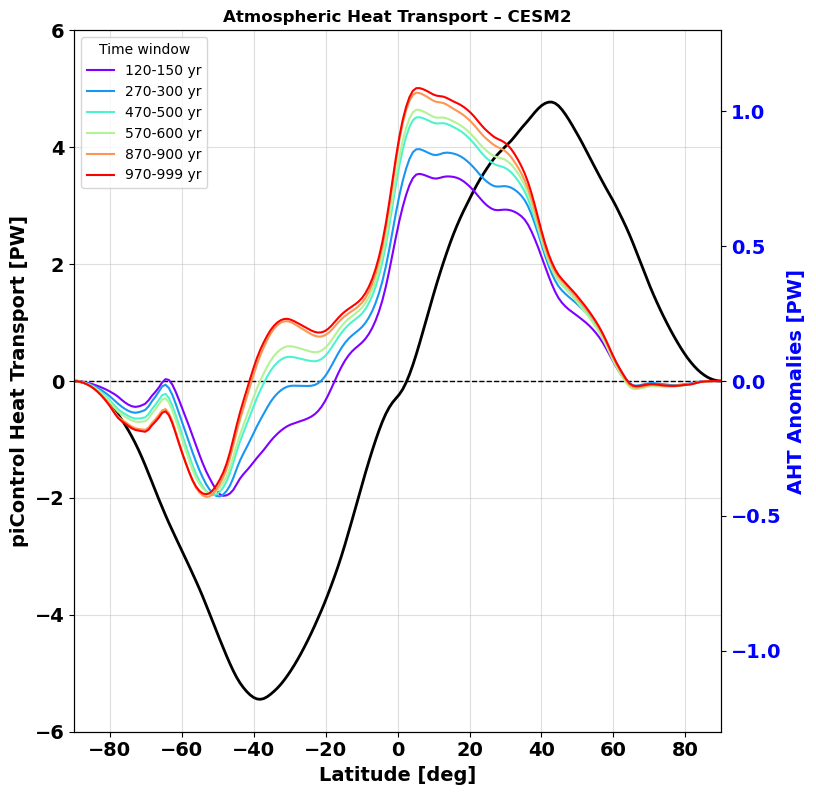

In [48]:
fig, ax1 = plt.subplots(figsize=(8, 8))

# --- Left axis (for control / baseline) ---
ax1.plot(lat_cesm2, np.mean(atm_ht_piControl, axis=0),
         color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [deg]', fontsize=14, fontweight='bold')
ax1.set_ylabel('piControl Heat Transport [PW]', color='black', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')

# --- Add zero line for ax1 ---
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

time_windows = [(120, 150), (270, 300), (470, 500), (570, 600),
                (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows, colors):
    anom = (np.mean(atm_ht_x4CO2[start:end, :], axis=0)\
          - np.mean(atm_ht_piControl[0:30, :], axis=0))
    ax2.plot(lat_cesm2, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('AHT Anomalies [PW]', color='blue', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

# --- Add zero line for ax2 ---
#ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, title="Time window")
ax1.set_ylim(-6, 6)
ax2.set_ylim(-1.3, 1.3)

plt.title('Atmospheric Heat Transport – CESM2', fontweight='bold')
plt.tight_layout()

# Make x-axis tick numbers stronger
ax1.tick_params(axis='x', labelsize=14)

# Left y-axis (piControl)
ax1.tick_params(axis='y', labelsize=14)

# Right y-axis (anomalies)
ax2.tick_params(axis='y', labelsize=14)

for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight('bold')

for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

plt.show()


#### *we also plot the anomalies (each year of x4CO2-the mean of the total piControl period) at 36 N/S

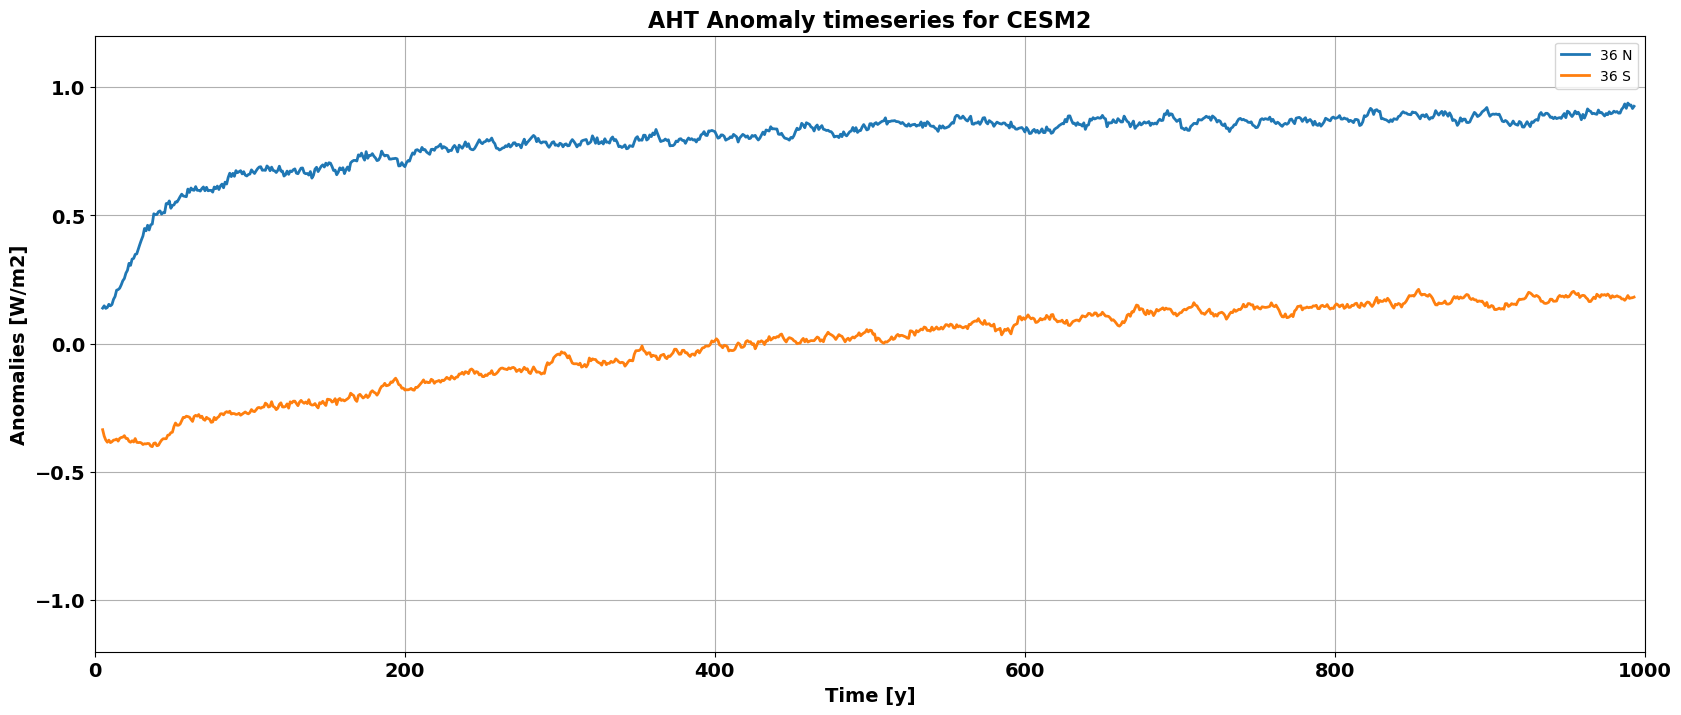

In [11]:
# Picking up the latitude closest to 36N/S

diff_N = np.abs(lat_cesm2 - 36)
min_diff_N = np.min(diff_N)

idx_36N = np.where(diff_N == min_diff_N)[0][0]
lat_36N = lat_cesm2[idx_36N]#.values

diff_S = np.abs(lat_cesm2 + 36)
min_diff_S = np.min(diff_S)

idx_36S = np.where(diff_S == min_diff_S)[0][0]
lat_36S = lat_cesm2[idx_36S]#.values

# Calculating the anomalies, compared to the whole piControl period

anom_aht_nh_cesm2 = atm_ht_x4CO2[0, :, idx_36N]-np.mean(atm_ht_piControl[:, idx_36N], axis =0)
anom_aht_sh_cesm2 = atm_ht_x4CO2[0, :, idx_36S]-np.mean(atm_ht_piControl[:, idx_36S], axis =0)

# Calculating the rolling mean

roll_anom_aht_nh_cesm2 = rolling_average_ts(anom_aht_nh_cesm2, 11)
roll_anom_aht_sh_cesm2 = rolling_average_ts(anom_aht_sh_cesm2, 11)

time = np.arange(5, 994)

plt.figure(figsize=(20, 8))
plt.plot(time, roll_anom_aht_nh_cesm2, linewidth = 2, label = '36 N')
plt.plot(time, roll_anom_aht_sh_cesm2, linewidth = 2, label = '36 S')

plt.xlim(0, 1000)
plt.ylim(-1.2, 1.2)
plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('Anomalies [W/m2]', fontsize=14, fontweight='bold')
plt.title(f'AHT Anomaly timeseries for CESM2', fontsize=16, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend()
plt.grid()

### **2.3. Regrid to a common grid**

*we do this because the grid of the ocean heat transport component (hfbasin) is not the same but eventually we will have to add those heat transports together.

In [46]:
# Regridding
target_lat = np.arange(-90, 92, 2)

toa_interp_piControl = regridding('CESM2', toa_ht_piControl, lat_cesm2, target_lat)
atm_interp_piControl = regridding('CESM2', atm_ht_piControl, lat_cesm2, target_lat)
toa_interp_x4CO2 = regridding('CESM2', toa_ht_x4CO2, lat_cesm2, target_lat)
atm_interp_x4CO2= regridding('CESM2', atm_ht_x4CO2, lat_cesm2, target_lat)

In [47]:
atm_exp_cesm2 = np.stack([atm_interp_piControl, atm_interp_x4CO2], axis=0)
toa_exp_cesm2 = np.stack([toa_interp_piControl, toa_interp_x4CO2], axis=0)

In [42]:
atm_interp_piControl.shape

(1099, 91)

### **Part 3: The Ocean Heat Transport**

source: https://app.globus.org/file-manager?origin_id=1ba8359d-eff0-41e9-b03b-dba7d0ae111e&origin_path=%2F

*we must work on the first year separately, as it starts in february and has only 11 months

### **3.1. Getting the output value for the ocean heat transport (hfbasin)**

In [49]:
hfbasin_y1 = []

for directory in ['piControl', 'x4CO2']:

    print(directory)
    
    folder_path = f'/home/chrikap/Desktop/atmospheric heat transport/heat transport datasets/Annual_Variations/CMIP6/Paper_Scripts/long_scale_cesm2/{directory}'
    file_names = sorted(os.listdir(folder_path))
    
    # Using dask to read datasets
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 11))

    ds_final = ds.isel(transport_reg = 0, transport_comp = 0)    
    
    hfbasin = ds_final['N_HEAT']

    hfbasin_y1.append(yearly_avg(hfbasin))
hfbasin_y1 = np.array(hfbasin_y1)

piControl
x4CO2


In [50]:
hfbasin_rest = []

for directory in ['piControl', 'x4CO2']:

    print(directory)
    
    folder_path = f'/home/chrikap/Desktop/atmospheric heat transport/heat transport datasets/Annual_Variations/CMIP6/Paper_Scripts/long_scale_cesm2/{directory}'
    file_names = sorted(os.listdir(folder_path))
    
    # Using dask to read datasets
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(11, 11987))
    
    ds_final = ds.isel(transport_reg = 0, transport_comp = 0)
    
    hfbasin = ds_final['N_HEAT']
    hfbasin_rest.append(yearly_avg(hfbasin))

hfbasin_rest = np.array(hfbasin_rest)

piControl
x4CO2


In [51]:
# Merging the 2 time slices together
oht_cesm2 = np.concatenate([hfbasin_y1, hfbasin_rest], axis = 1)

In [52]:
# Separating the latitude, so we can use it later
oc_lat_cesm2 = ds_final['N_HEAT']['lat_aux_grid']

In [9]:
os.chdir('/home/chrikap/Desktop/atmospheric heat transport/heat transport datasets/Annual_Variations/CMIP6/Paper_Scripts/long_scale_cesm2')

#np.save('oht_cesm2', oht_cesm2)
#np.save('oc_lat_cesm2', oc_lat_cesm2)

### **3.2. Loading the data and plotting**

In [19]:
oht_cesm2 = np.load('oht_cesm2.npy')
oc_lat_cesm2 = np.load('oc_lat_cesm2.npy')

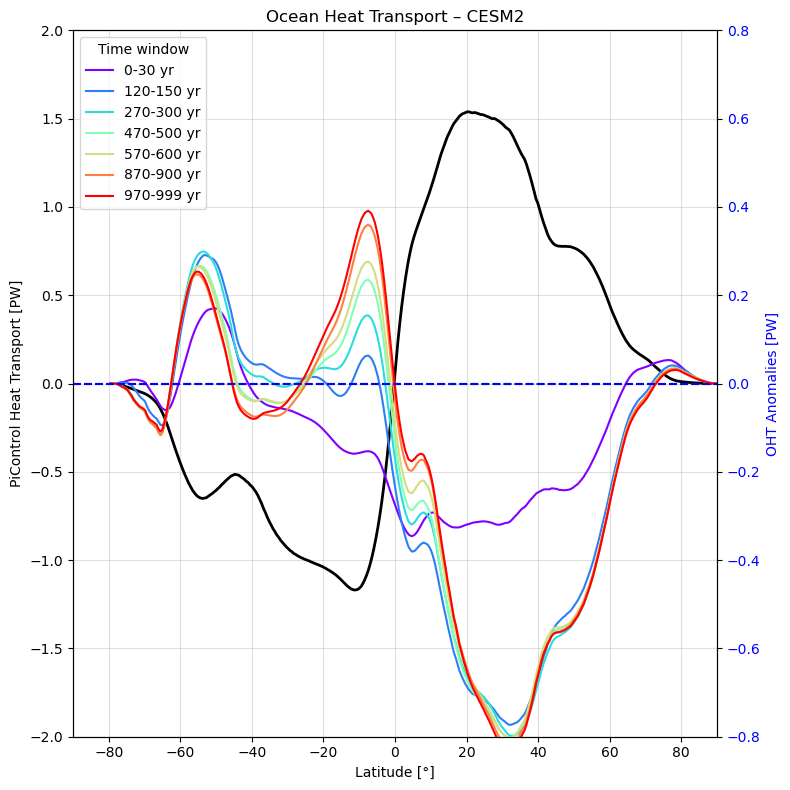

In [53]:
fig, ax1 = plt.subplots(figsize=(8, 8))

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_cesm2, np.mean(oht_cesm2[0, :, :], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows, colors):
    anom = (np.mean(oht_cesm2[1, start:end, :], axis=0)\
          - np.mean(oht_cesm2[0, 0:30, :], axis=0))
    
    ax2.plot(oc_lat_cesm2, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax1.axhline(0, color='black', linestyle='--')
ax2.axhline(0, color='blue', linestyle='--')
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, title="Time window")

plt.title('Ocean Heat Transport – CESM2')
plt.tight_layout()
plt.show()

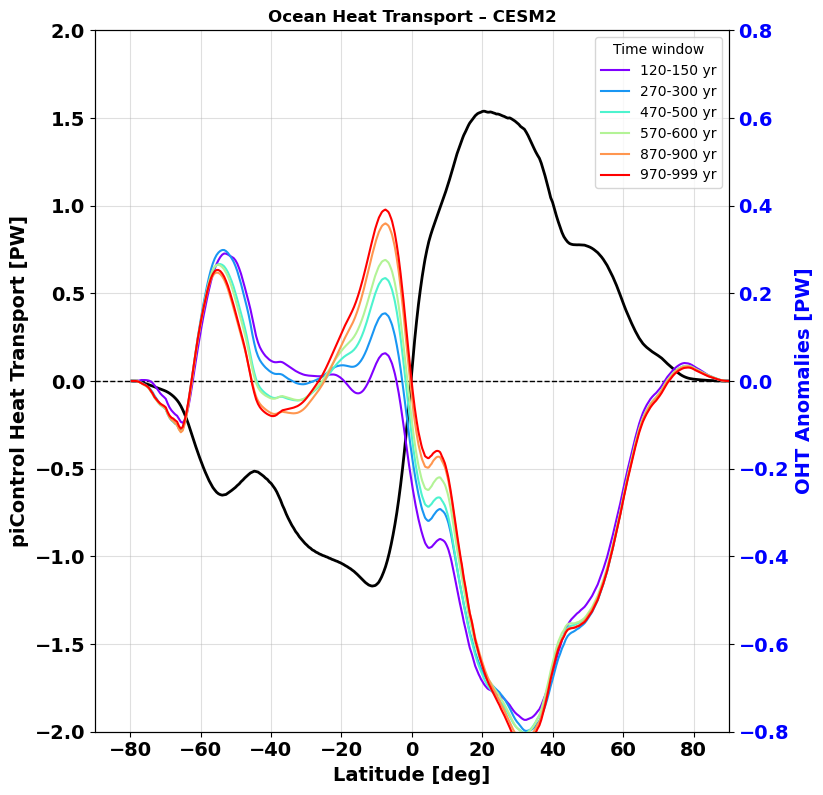

In [13]:
fig, ax1 = plt.subplots(figsize=(8, 8))

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_cesm2, np.mean(oht_cesm2[0, :, :], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [deg]', fontsize=14, fontweight='bold')
ax1.set_ylabel('piControl Heat Transport [PW]', color='black', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')

# --- Add zero line for ax1 ---
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

time_windows = [(120, 150), (270, 300), (470, 500), (570, 600),
                (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows, colors):
    anom = (np.mean(oht_cesm2[1, start:end, :], axis=0)\
          - np.mean(oht_cesm2[0, 0:30, :], axis=0))
    
    ax2.plot(oc_lat_cesm2, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('OHT Anomalies [PW]', color='blue', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

# --- Add zero line for ax2 ---
#ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper right', fontsize=10, title="Time window")

plt.title('Ocean Heat Transport – CESM2', fontweight='bold')
plt.tight_layout()

# Make x-axis tick numbers stronger
ax1.tick_params(axis='x', labelsize=14)

# Left y-axis (piControl)
ax1.tick_params(axis='y', labelsize=14)

# Right y-axis (anomalies)
ax2.tick_params(axis='y', labelsize=14)

for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight('bold')

for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

plt.show()


#### *we also plot the anomalies (each year of x4CO2-the mean of the total piControl period) at 36 N/S

<Figure size 2000x800 with 0 Axes>

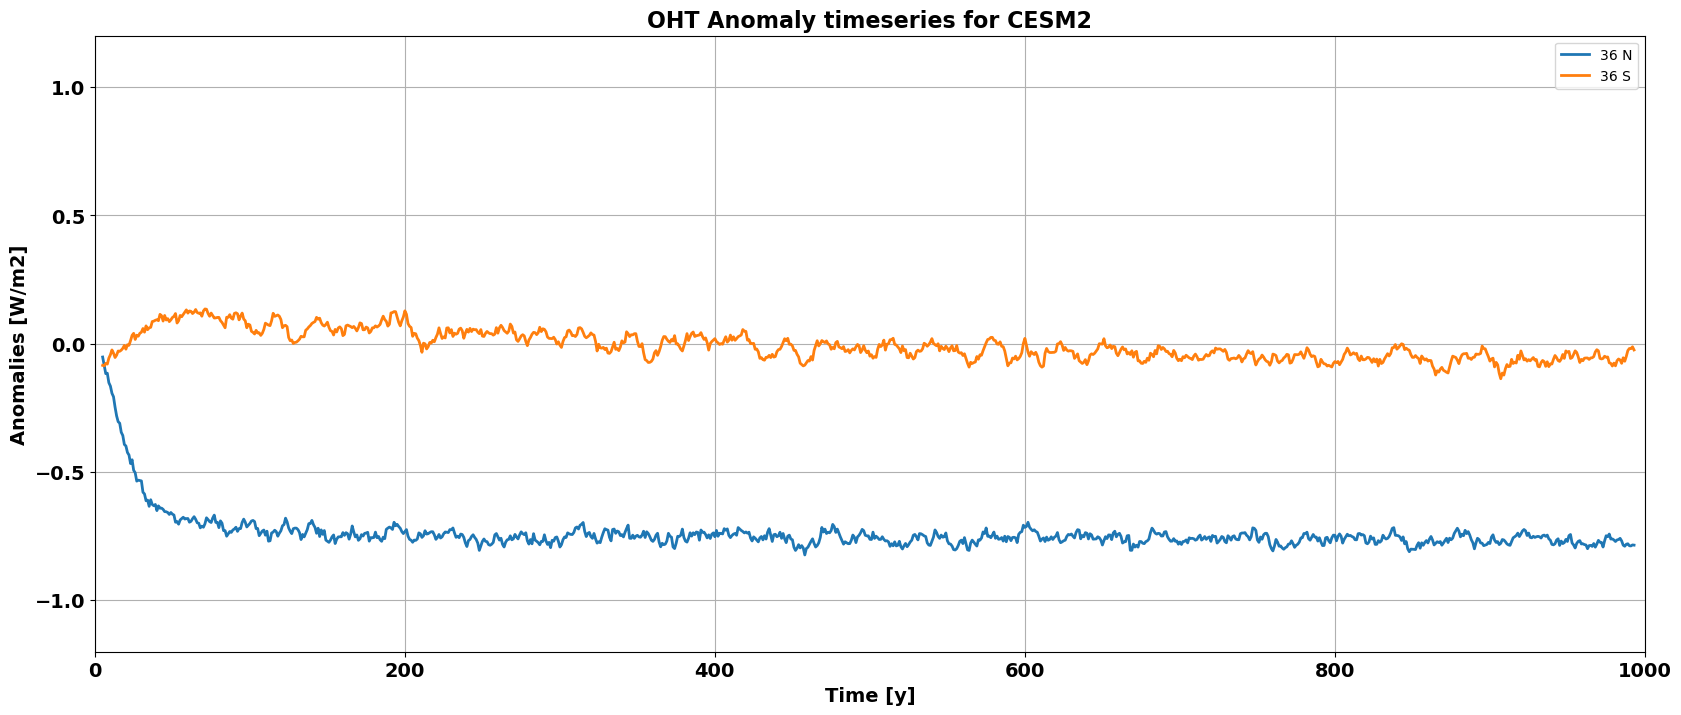

In [17]:
diff_N = np.abs(oc_lat_cesm2 - 36)
min_diff_N = np.min(diff_N)

idx_36N = np.where(diff_N == min_diff_N)[0][0]
lat_36N = oc_lat_cesm2[idx_36N].values

diff_S = np.abs(oc_lat_cesm2 + 36)
min_diff_S = np.min(diff_S)

idx_36S = np.where(diff_S == min_diff_S)[0][0]
lat_36S = oc_lat_cesm2[idx_36S].values

time = np.arange(5, 994)
plt.figure(figsize=(20, 8))

anom_oht_nh_cesm2 = oht_cesm2[1, :, idx_36N]-np.mean(oht_cesm2[0, :, idx_36N], axis =0)
anom_oht_sh_cesm2 = oht_cesm2[1, :, idx_36S]-np.mean(oht_cesm2[0, :, idx_36S], axis =0)

roll_anom_oht_nh_cesm2 = rolling_average_ts(anom_oht_nh_cesm2, 11)
roll_anom_oht_sh_cesm2 = rolling_average_ts(anom_oht_sh_cesm2, 11)

time = np.arange(5, 994)

plt.figure(figsize=(20, 8))

plt.plot(time, roll_anom_oht_nh_cesm2, linewidth = 2, label = '36 N')

plt.plot(time, roll_anom_oht_sh_cesm2, linewidth = 2, label = '36 S')

plt.xlim(0, 1000)
plt.ylim(-1.2, 1.2)
plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('Anomalies [W/m2]', fontsize=14, fontweight='bold')
plt.title(f'OHT Anomaly timeseries for CESM2', fontsize=16, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend()
plt.grid()

### **2.3. Regrid to a common grid**

In [54]:
oht_cesm2 = ocean_regr_vec(oht_cesm2, oc_lat_cesm2, target_lat)

*Checking for nan values. If they appear only in the SH, where Antarctica is, then we can replace them with 0

In [15]:
for i in range (2):
    for j in range(999):
        print(target_lat[np.where(np.isnan(oht_cesm2[i, j, :]))])

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[

In [16]:
for i in range(2):
    for j in range(999):
        print(target_lat[np.where(oht_cesm2[i, j, :] < -10)])
        if np.any(oht_cesm2[i, j] < -10):
            print(i, j)

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[

In [17]:
# So now, we can replace them with 0:

oht_cesm2 = np.nan_to_num(oht_cesm2, nan=0)

### **Part 4: The Atmosphere + Ocean Heat Transport**

In [55]:
# Now that both AHT and OHT are in a common grid, we can add them together
toa_sum_cesm2 = atm_exp_cesm2 + oht_cesm2

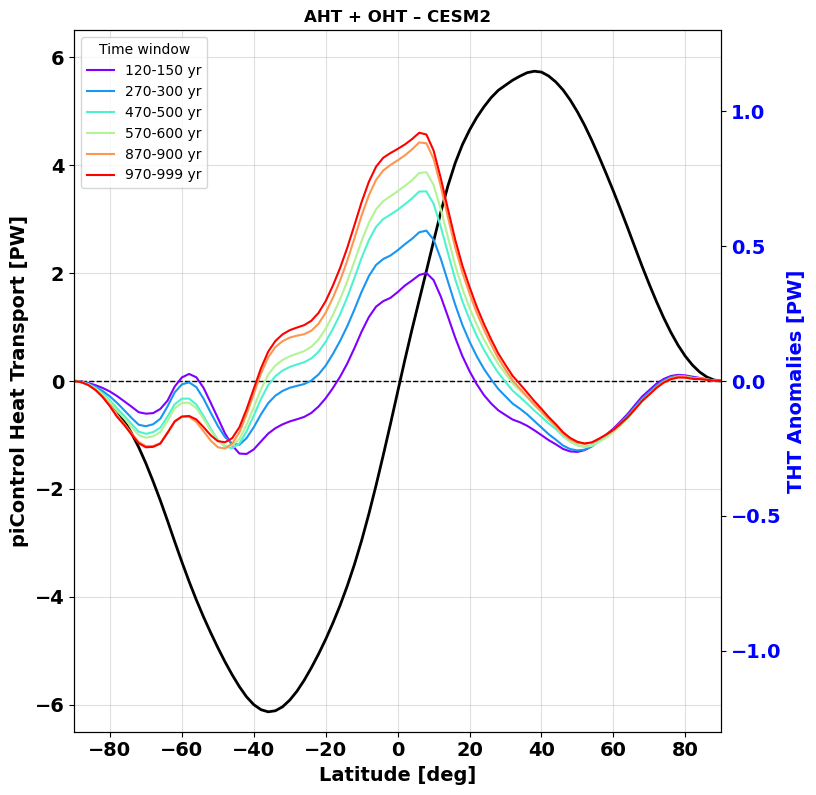

In [57]:
fig, ax1 = plt.subplots(figsize=(8, 8))

# --- Left axis (for control / baseline) ---
ax1.plot(target_lat, np.mean(toa_sum_cesm2[0, :, :], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [deg]', fontsize=14, fontweight='bold')
ax1.set_ylabel('piControl Heat Transport [PW]', color='black', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')

# --- Add zero line for ax1 ---
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

time_windows = [(120, 150), (270, 300), (470, 500), (570, 600),
                (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows, colors):
    anom = (np.mean(toa_sum_cesm2[1, start:end, :], axis=0)\
          - np.mean(toa_sum_cesm2[0, 0:30, :], axis=0))
    
    ax2.plot(target_lat, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('THT Anomalies [PW]', color='blue', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

# --- Add zero line for ax2 ---
#ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.set_ylim(-6.5, 6.5)
ax2.set_ylim(-1.3, 1.3)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, title="Time window")

plt.title('AHT + OHT – CESM2', fontweight = 'bold')
plt.tight_layout()

# Make x-axis tick numbers stronger
ax1.tick_params(axis='x', labelsize=14)

# Left y-axis (piControl)
ax1.tick_params(axis='y', labelsize=14)

# Right y-axis (anomalies)
ax2.tick_params(axis='y', labelsize=14)

for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight('bold')

for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

plt.show()


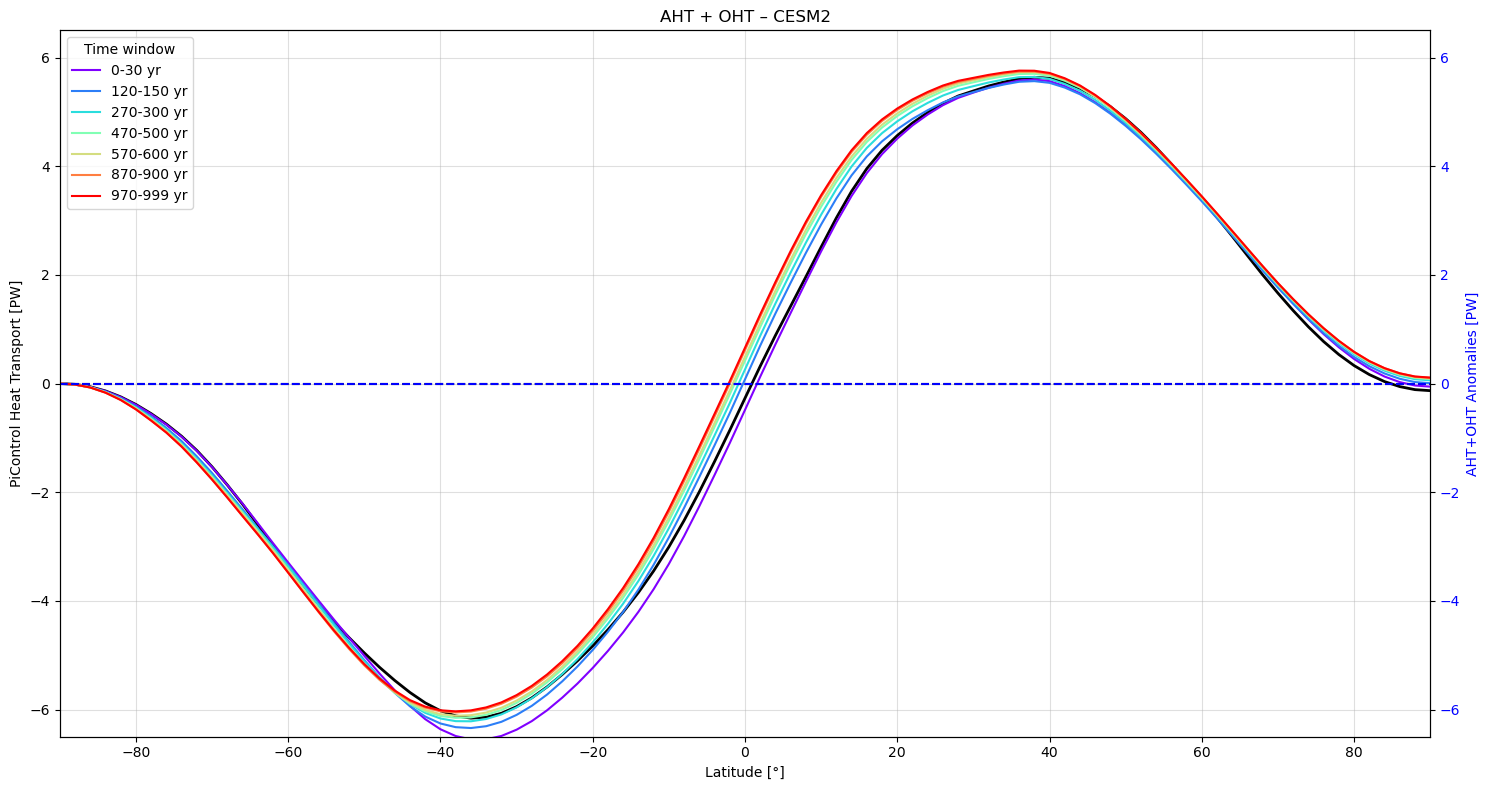

In [19]:
fig, ax1 = plt.subplots(figsize=(15, 8))

# --- Left axis (for control / baseline) ---
ax1.plot(target_lat, np.mean(toa_sum_cesm2[0, :, :], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows, colors):
    x4 = (np.mean(toa_sum_cesm2[1, start:end, :], axis=0))
    
    ax2.plot(target_lat, x4, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('AHT+OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax1.axhline(0, color='black', linestyle='--')
ax2.axhline(0, color='blue', linestyle='--')
ax1.set_ylim(-6.5, 6.5)
ax2.set_ylim(-6.5, 6.5)
#ax2.set_ylim(-1.3, 1.3)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, title="Time window")

plt.title('AHT + OHT – CESM2')
plt.tight_layout()
plt.show()

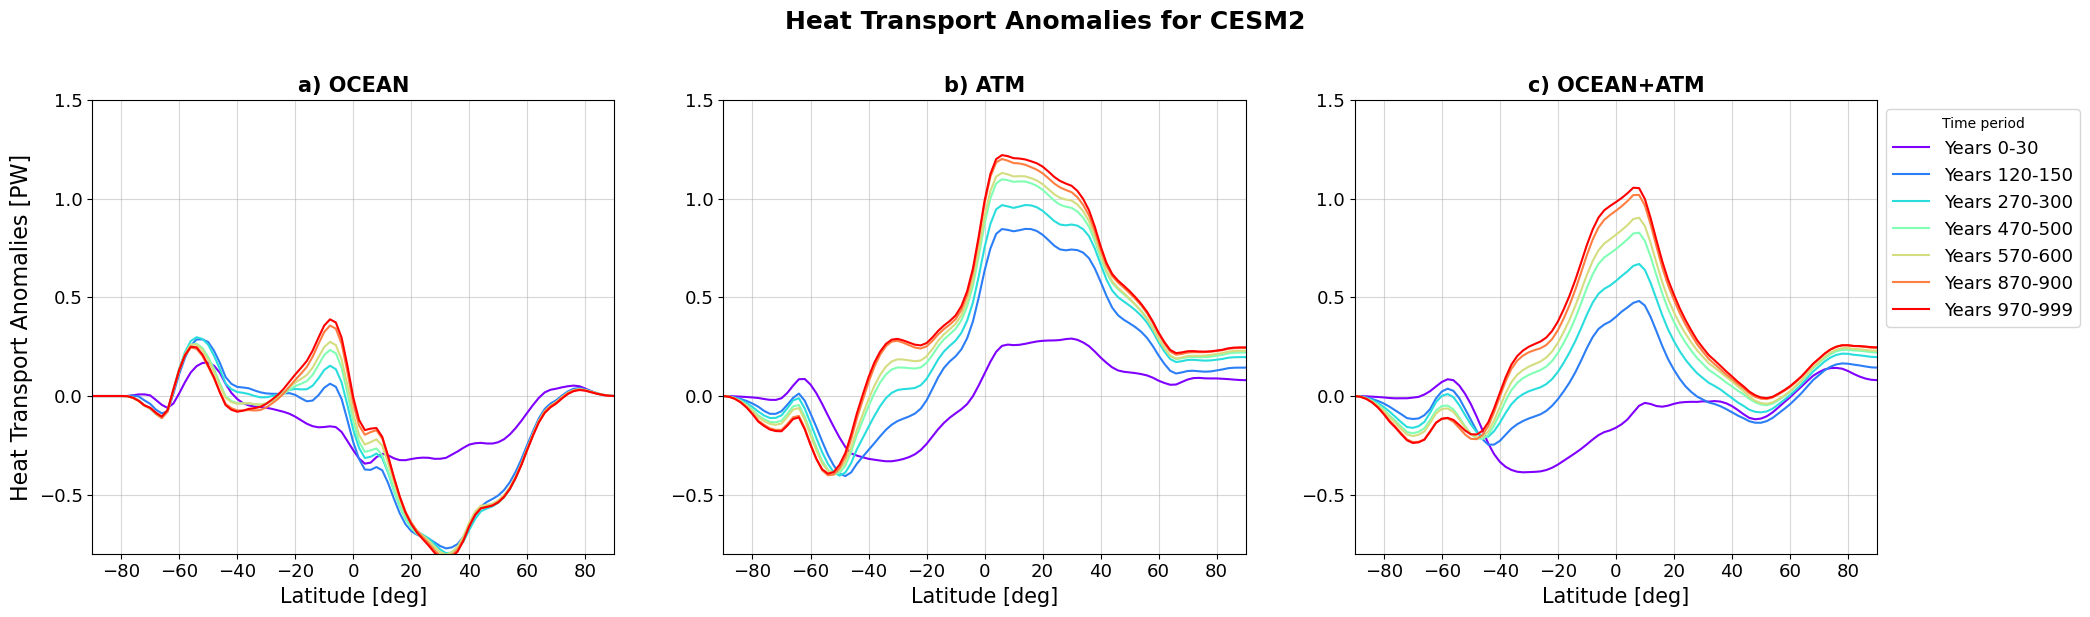

In [27]:
ht_plots ('CESM2', 999, atm_exp_cesm2, oht_cesm2, toa_sum_cesm2, target_lat, None)

### **Part 5: Joe's metric of BJC**

In [26]:
toa_sum_cesm2.shape

(2, 999, 91)

In [29]:
anom.shape

(34, 91)

In [28]:
anom = np.array([(np.mean(toa_sum_cesm2[1, i:i+30, :], axis=0) - np.mean(toa_sum_cesm2[0, 0:30, :], axis=0)) for i in range(0, 1000, 30)]) 

bounds_1 = [(-10, 10), (-10, 10), (-10, 10)]  # Assuming c is in [0, 10]
x_data = np.arange(anom.shape[0])

a_coeffs = []
b_coeffs = []
c_coeffs = []
rms = []
y_fit_all = []

for i in range(len(anom[0])):

    y_data = anom[:, i]
    
    result = differential_evolution(objective_function_1, bounds_1, args=(x_data, y_data), maxiter=1000)
    
    a1, b1, c = result.x

    if i ==40:
        print(a1, b1, c)
    
    y_fit = single_exponential(x_data, a1, b1, c)
    
    rms_error = np.sqrt(np.mean((y_data - y_fit) ** 2))
    a_coeffs.append(a1)
    b_coeffs.append(b1)
    c_coeffs.append(c)
    rms.append(rms_error)
    y_fit_all.append(y_fit)

y_fit_all = np.array(y_fit_all)

-0.82080047216507 -0.10857460358756586 0.7305829972371833


In [38]:
np.where(target_lat==10)

(array([50]),)

Text(0, 0.5, 'tendency of anomalies [PW/y]')

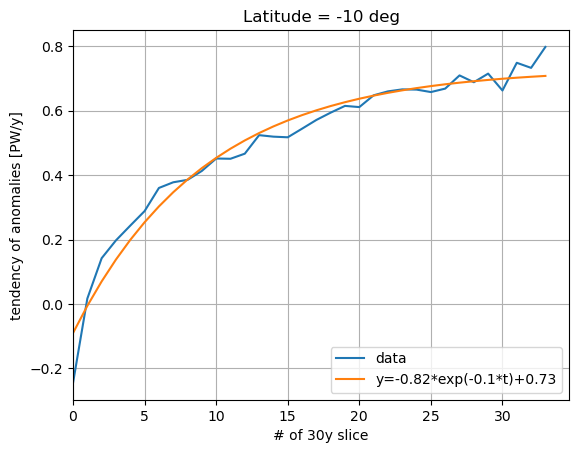

In [30]:
plt.plot(x_data, anom[:, 40], label = 'data')
plt.plot(x_data, y_fit_all[40, :], label = 'y=-0.82*exp(-0.1*t)+0.73')
#plt.plot(x_data, -0.8207953158120238*np.exp(-0.1085749411187615*x_data)+0.7305807080695651)

plt.title('Latitude = -10 deg')
plt.grid()
plt.xlim(0, )
plt.legend(loc = 'lower right')
plt.xlabel('# of 30y slice')
plt.ylabel('tendency of anomalies [PW/y]')

Text(0, 0.5, 'b coeff')

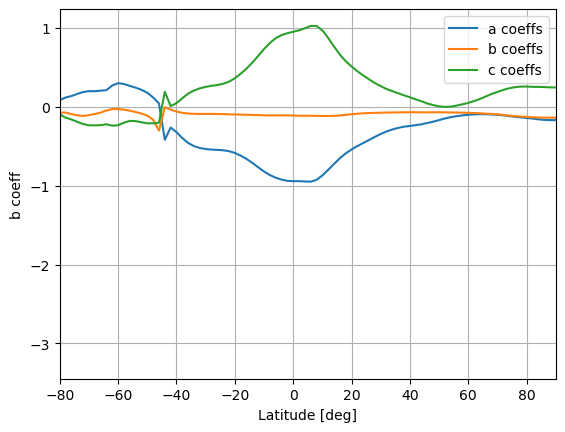

In [31]:
plt.plot(target_lat, a_coeffs, label = 'a coeffs')
plt.plot(target_lat, b_coeffs, label = 'b coeffs')
plt.plot(target_lat, c_coeffs, label = 'c coeffs')
plt.grid()
plt.xlim(-80, 90)
#plt.ylim(-1,)
plt.legend(loc = 'upper right')
plt.xlabel('Latitude [deg]')
plt.ylabel('b coeff')